# Analisi Temporale del Sentiment di post su Bluesky

Questo notebook riproduce e documenta l'intera pipeline di elaborazione, classificazione del sentiment, validazione locale con LLM e modellazione dei topic (BERTopic) descritta nella relazione di progetto.

In [3]:
import sys
import os
import re
import json
from collections import defaultdict, Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import nltk
from nltk.corpus import stopwords

from transformers import pipeline
from openai import OpenAI
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from bertopic import BERTopic

# Aggiungiamo la cartella src al path per importare moduli locali
sys.path.append('src')
from preprocessing import TextPreprocessor
from models import SentimentAnalyzer

sns.set_theme(style='whitegrid')


c:\dev\nlp\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Caricamento e Preprocessing dei Dati

Carichiamo la serie temporale estratta da Bluesky nell'intervallo temporale dal **01-01-2026** al **18-06-2026** (13.465 post unici). Applichiamo le operazioni di preprocessing per eliminare URL, menzioni utente (evitando elementi di rumore nel dataset), ed effettuiamo la normalizzazione degli hashtag (rimuovendo solo il cancelletto `#`) e il lowercasing dei caratteri.

In [4]:
PATH = 'datasets/bluesky_time_series_data.csv'

df = pd.read_csv(PATH)
df.head()


,id,cid,created_at,indexed_at,text_raw,text_clean,hashtags,keyword_source,author_did,author_handle,...,author_createdAt,like_count,repost_count,reply_count,quote_count,bookmark_count,viewer_like,viewer_repost,viewer_pinned,viewer_bookmarked
0,at://did:plc:574o3rvmxpg6iq3x5ng2ncgf/app.bsky...,bafyreiehhr3ijy2ey6cqo47vzd4axwnh7dj6nu5mlrd4o...,2026-01-01T22:07:40.882Z,2026-01-01T22:07:41.631Z,Meloni sente Trump e frena sul Donbass: “Decid...,meloni sente trump e frena sul donbass decidon...,[],meloni,did:plc:574o3rvmxpg6iq3x5ng2ncgf,mediasit.skyfleet.blue,...,2023-08-27T20:23:54.944Z,0,0,0,1,0,NaN,NaN,NaN,False
1,at://did:plc:m3yth7migrk4nguhrtaesc7m/app.bsky...,bafyreigeeb5um7gzy6mkph7mddov3pe4phwdqi5fg5fbw...,2026-01-01T21:46:16.847Z,2026-01-01T21:46:17.632Z,Questo è il grafico che certifica che la Melon...,questo è il grafico che certifica che la melon...,[],meloni,did:plc:m3yth7migrk4nguhrtaesc7m,texwiller.bsky.social,...,2023-11-28T06:45:55.936Z,2,0,0,0,0,NaN,NaN,NaN,False
2,at://did:plc:6tngxystbigl4pm6ffr4jhi2/app.bsky...,bafyreiaefdsy3srmd64pwpr7kxuek5sun6w2ramzr6tsm...,2026-01-01T20:29:57.043Z,2026-01-01T20:30:03.734Z,"🚨 Italia \nMeloni ""abbiamo mantenuto tutte le ...",italia meloni abbiamo mantenuto tutte le prome...,[],meloni,did:plc:6tngxystbigl4pm6ffr4jhi2,lacanoggi.eurosky.social,...,2024-02-10T11:17:52.005Z,7,0,0,0,0,NaN,NaN,NaN,False
3,at://did:plc:574o3rvmxpg6iq3x5ng2ncgf/app.bsky...,bafyreibwstadcqczbu5c3cegor4ifncke7aa3hbyjgytl...,2026-01-01T20:06:05.379Z,2026-01-01T20:06:06.149Z,"Meloni elogia il Colle, ma la Repubblica di Gi...",meloni elogia il colle ma la repubblica di gio...,[],meloni,did:plc:574o3rvmxpg6iq3x5ng2ncgf,mediasit.skyfleet.blue,...,2023-08-27T20:23:54.944Z,0,0,0,0,0,NaN,NaN,NaN,False
4,at://did:plc:ngbx3rfvovh2bmgueezurs4w/app.bsky...,bafyreieiwnjtxs7yzw5brgcmtwtp65mqnrhpgqpdamrkm...,2026-01-01T18:00:44+01:00,2026-01-01T17:00:45.034Z,La superbia di Giorgia meloni https://www.gayb...,la superbia di giorgia meloni,[],meloni,did:plc:ngbx3rfvovh2bmgueezurs4w,gayburg.bsky.social,...,2024-11-18T19:04:09.447Z,1,0,0,0,0,NaN,NaN,NaN,False


tolgo maiuscole, numeri, url, menzioni e hashtag

In [3]:
preprocessor = TextPreprocessor()

df['text_clean'] = df['text_raw'].astype(str).apply(preprocessor.clean_text)

df['created_at'] = pd.to_datetime(df['created_at'], format='ISO8601', utc=True)
df['date'] = df['created_at'].dt.date

df.head()

,id,cid,created_at,indexed_at,text_raw,text_clean,hashtags,keyword_source,author_did,author_handle,...,like_count,repost_count,reply_count,quote_count,bookmark_count,viewer_like,viewer_repost,viewer_pinned,viewer_bookmarked,date
0,at://did:plc:574o3rvmxpg6iq3x5ng2ncgf/app.bsky...,bafyreiehhr3ijy2ey6cqo47vzd4axwnh7dj6nu5mlrd4o...,2026-01-01 22:07:40.882000+00:00,2026-01-01T22:07:41.631Z,Meloni sente Trump e frena sul Donbass: “Decid...,meloni sente trump e frena sul donbass decidon...,[],meloni,did:plc:574o3rvmxpg6iq3x5ng2ncgf,mediasit.skyfleet.blue,...,0,0,0,1,0,NaN,NaN,NaN,False,2026-01-01
1,at://did:plc:m3yth7migrk4nguhrtaesc7m/app.bsky...,bafyreigeeb5um7gzy6mkph7mddov3pe4phwdqi5fg5fbw...,2026-01-01 21:46:16.847000+00:00,2026-01-01T21:46:17.632Z,Questo è il grafico che certifica che la Melon...,questo è il grafico che certifica che la melon...,[],meloni,did:plc:m3yth7migrk4nguhrtaesc7m,texwiller.bsky.social,...,2,0,0,0,0,NaN,NaN,NaN,False,2026-01-01
2,at://did:plc:6tngxystbigl4pm6ffr4jhi2/app.bsky...,bafyreiaefdsy3srmd64pwpr7kxuek5sun6w2ramzr6tsm...,2026-01-01 20:29:57.043000+00:00,2026-01-01T20:30:03.734Z,"🚨 Italia \nMeloni ""abbiamo mantenuto tutte le ...",italia meloni abbiamo mantenuto tutte le prome...,[],meloni,did:plc:6tngxystbigl4pm6ffr4jhi2,lacanoggi.eurosky.social,...,7,0,0,0,0,NaN,NaN,NaN,False,2026-01-01
3,at://did:plc:574o3rvmxpg6iq3x5ng2ncgf/app.bsky...,bafyreibwstadcqczbu5c3cegor4ifncke7aa3hbyjgytl...,2026-01-01 20:06:05.379000+00:00,2026-01-01T20:06:06.149Z,"Meloni elogia il Colle, ma la Repubblica di Gi...",meloni elogia il colle ma la repubblica di gio...,[],meloni,did:plc:574o3rvmxpg6iq3x5ng2ncgf,mediasit.skyfleet.blue,...,0,0,0,0,0,NaN,NaN,NaN,False,2026-01-01
4,at://did:plc:ngbx3rfvovh2bmgueezurs4w/app.bsky...,bafyreieiwnjtxs7yzw5brgcmtwtp65mqnrhpgqpdamrkm...,2026-01-01 17:00:44+00:00,2026-01-01T17:00:45.034Z,La superbia di Giorgia meloni https://www.gayb...,la superbia di giorgia meloni,[],meloni,did:plc:ngbx3rfvovh2bmgueezurs4w,gayburg.bsky.social,...,1,0,0,0,0,NaN,NaN,NaN,False,2026-01-01


## 2. Sentiment Analysis e Calcolo dello Score Continuo

Definiamo una metrica per mappare le probabilità stimate dai modelli Transformer in un valore continuo $S \in [0, 1]$:

$$S = 0.5 + \frac{P(\text{positive}) - P(\text{negative})}{2}$$

Le soglie per determinare le classi discrete di sentiment sono:
* **Sentiment Negativo**: $S < 0.45$
* **Sentiment Neutrale**: $S \in [0.45, 0.55]$
* **Sentiment Positivo**: $S > 0.55$

Questo approccio permette di visualizzare l'andamento del sentiment nel tempo e identificare i picchi di volume.

In [1]:

def print_report(dataframe, column_name):
    print(f"modello: {column_name}")
    print(dataframe[f'sentiment_{column_name}'].value_counts())

    colors_dict = {
        'negative': '#e74c3c',
        'neutral': '#95a5a6',
        'positive': '#2ecc71'
    }

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    sns.countplot(
        x=f'sentiment_{column_name}', 
        data=dataframe, 
        order=['negative', 'neutral', 'positive'],
        palette=colors_dict,
        ax=axes[0]
    )
    axes[0].set_title(f"Distribuzione Sentiment ({column_name})")

    df_time_ml = dataframe.groupby(['date', f'sentiment_{column_name}']).size().unstack(fill_value=0)
    df_time_ml = df_time_ml.reindex(columns=['negative', 'neutral', 'positive'], fill_value=0)
    
    df_time_ml.plot(
        kind='line', 
        marker='o', 
        color=[colors_dict['negative'], colors_dict['neutral'], colors_dict['positive']], 
        ax=axes[1]
    )
    axes[1].set_title(f"Andamento del Sentiment nel Tempo ({column_name})")
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

def save_dataframe_to_csv(dataframe, filename):
    dataframe.to_csv(filename, index=False)
    print(f"DataFrame salvato in {filename}")

In [5]:
analyzer = SentimentAnalyzer()

modello: multilingua
sentiment_multilingua
negative    11359
positive     1111
neutral       995
Name: count, dtype: int64


C:\Users\vitog\AppData\Local\Temp\ipykernel_22484\2831483860.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


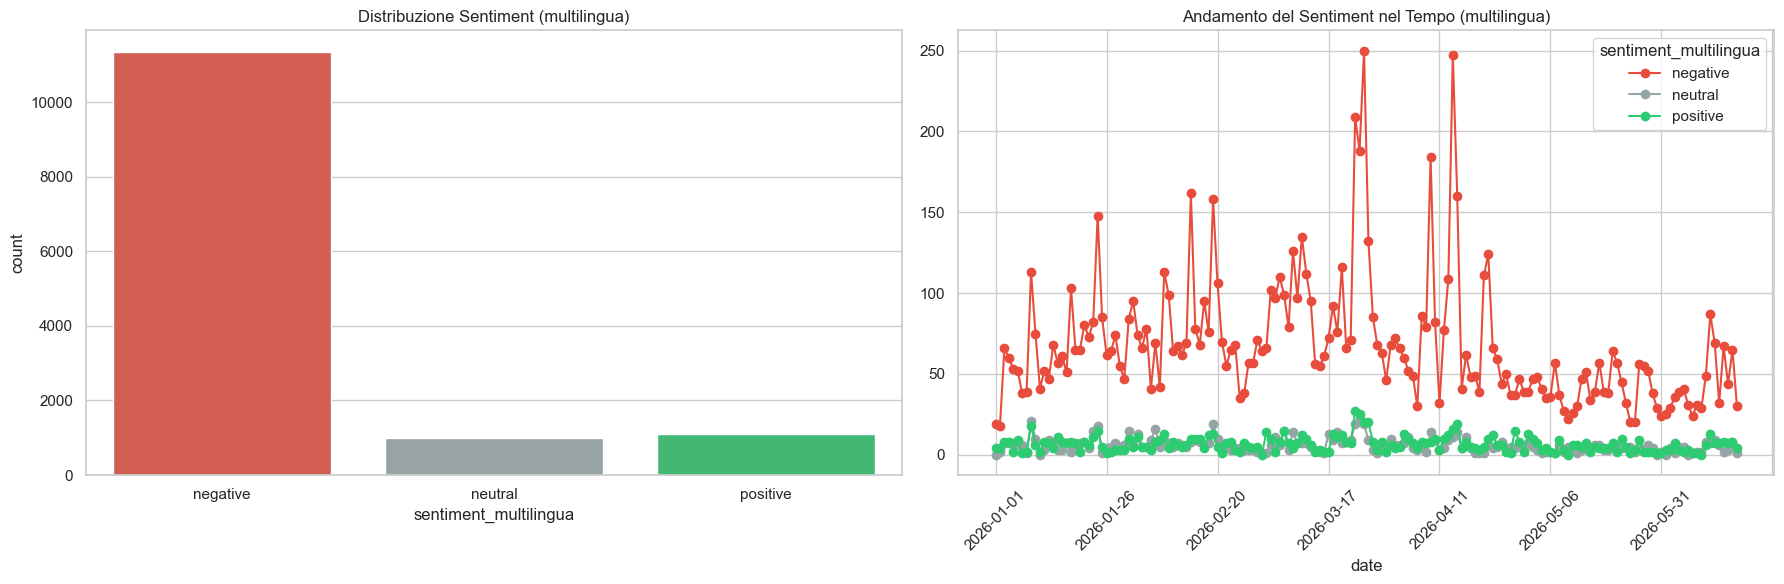

In [6]:

if os.path.exists('output/cardiffnlp_multilingua.csv'):
    df = pd.read_csv('output/cardiffnlp_multilingua.csv')
else:
    df = analyzer.analyze_dataset_custom(df, 'cardiffnlp/twitter-xlm-roberta-base-sentiment', custom_name='multilingua')
    save_dataframe_to_csv(df, 'output/cardiffnlp_multilingua.csv')
print_report(df, 'multilingua')



modello: italiano
sentiment_italiano
negative    12642
positive      806
neutral        17
Name: count, dtype: int64


C:\Users\vitog\AppData\Local\Temp\ipykernel_3536\2831483860.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


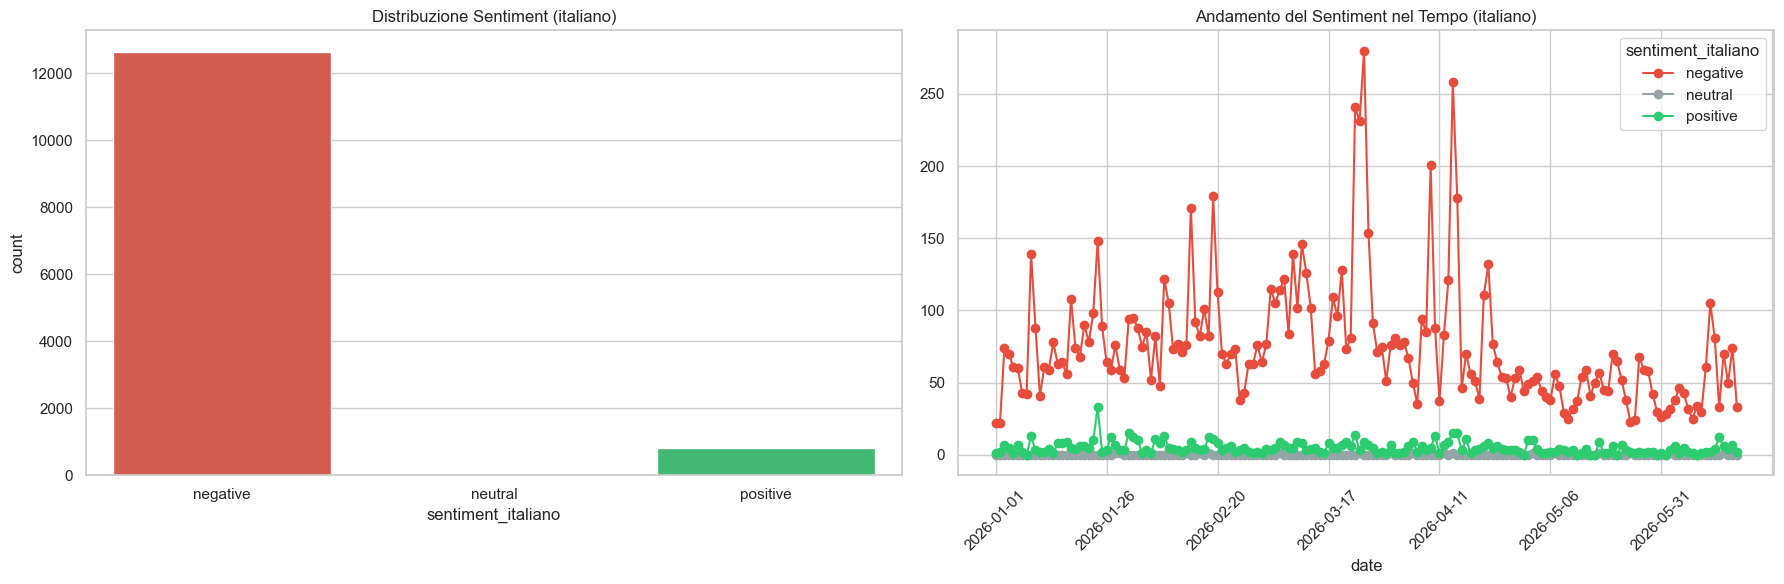

In [7]:
if os.path.exists('output/MilaNLProc_italiano.csv'):
    df = pd.read_csv('output/MilaNLProc_italiano.csv')
else:
    df = analyzer.analyze_dataset_custom(df, 'MilaNLProc/feel-it-italian-sentiment', custom_name='italiano')

    save_dataframe_to_csv(df, 'output/MilaNLProc_italiano.csv')
print_report(df, 'italiano')


modello: multilingua_v2
sentiment_multilingua_v2
neutral     10725
positive     2002
negative      738
Name: count, dtype: int64


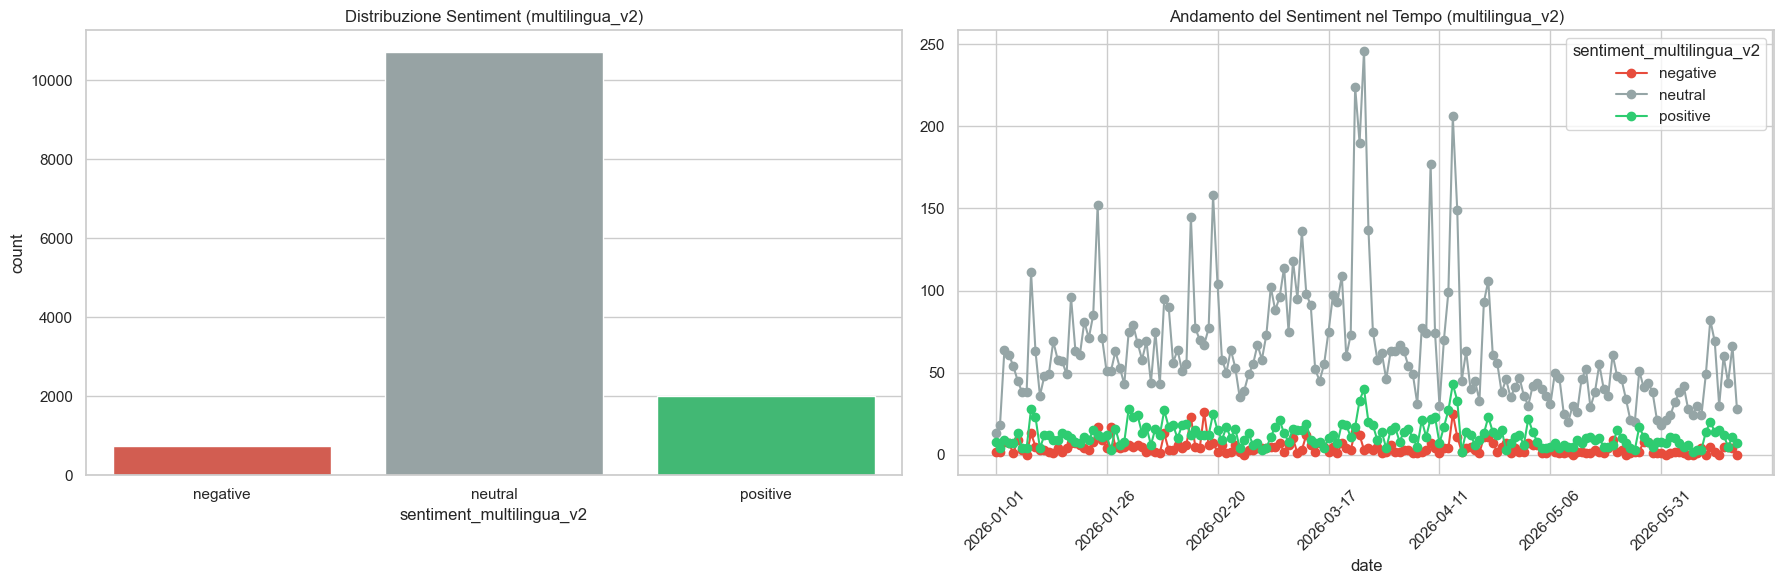

In [18]:
if os.path.exists('output/cardiffnlp_multilingua_v2.csv'):
    df = pd.read_csv('output/cardiffnlp_multilingua_v2.csv')
else:
    df = analyzer.analyze_dataset_custom(df, 'cardiffnlp/twitter-roberta-base-sentiment-latest', custom_name='multilingua_v2')
    save_dataframe_to_csv(df, 'output/cardiffnlp_multilingua_v2.csv')
    
print_report(df, 'multilingua_v2')



In [19]:
df_ml = pd.read_csv(r'output/cardiffnlp_multilingua_v2.csv')

df_disaccordo = df_ml[df_ml['sentiment_multilingua_v2'] != df_ml['sentiment_italiano']]
df_accordo = df_ml[df_ml[f'sentiment_multilingua_v2'] == df_ml['sentiment_italiano']]

print(f"Numero di casi in disaccordo: {len(df_disaccordo)}")
print(f"Numero di casi in accordo: {len(df_accordo)}")  

df_time_ml = df_ml.sample(min(50, len(df_ml)), random_state=42)
sample_disaccordo = df_time_ml.sample(min(50, len(df_time_ml)), random_state=42)

df_sample = pd.concat([df_time_ml, df_time_ml]).drop_duplicates(subset=['id']).sample(frac=1, random_state=42)

df_sample.head()

Numero di casi in disaccordo: 12550
Numero di casi in accordo: 915


,id,cid,created_at,indexed_at,text_raw,text_clean,hashtags,keyword_source,author_did,author_handle,...,viewer_repost,viewer_pinned,viewer_bookmarked,date,sent_multilingua_score,sentiment_multilingua,sent_italiano_score,sentiment_italiano,sent_multilingua_v2_score,sentiment_multilingua_v2
13141,at://did:plc:m3yth7migrk4nguhrtaesc7m/app.bsky...,bafyreie6wkoa6yr74k5odawktzzpnvglax6b765grfx6p...,2026-06-12 08:07:00.150000+00:00,2026-06-12T08:07:00.866Z,"Meloni ha ragione, non è una Repubblica delle ...",meloni ha ragione non è una repubblica delle b...,[],meloni,did:plc:m3yth7migrk4nguhrtaesc7m,texwiller.bsky.social,...,NaN,NaN,False,2026-06-12,0.167563,negative,0.000204,negative,0.478180,neutral
9593,at://did:plc:4l7zuasze3mxhxcytdrmtegg/app.bsky...,bafyreickiwbwkbddh3ohwpkkjwr7u47sairjo5jors2pu...,2026-04-13 07:35:43.136000+00:00,2026-04-13T07:35:44.753Z,"No, certo, e il tizio che hanno eletto comunqu...",no certo e il tizio che hanno eletto comunque ...,[],meloni,did:plc:4l7zuasze3mxhxcytdrmtegg,pierluigi1973.bsky.social,...,NaN,NaN,False,2026-04-13,0.214447,negative,0.000225,negative,0.479045,neutral
6651,at://did:plc:4l7zuasze3mxhxcytdrmtegg/app.bsky...,bafyreic4bvl4u3hvgi4wfl6hnecveuhorqhciyvv4lqrv...,2026-03-18 16:34:33.654000+00:00,2026-03-18T16:34:35.348Z,"Ora ho letto.\nBeh, a me fa tanto pensare che ...",ora ho letto beh a me fa tanto pensare che abb...,[],meloni,did:plc:4l7zuasze3mxhxcytdrmtegg,pierluigi1973.bsky.social,...,NaN,NaN,False,2026-03-18,0.081548,negative,0.000203,negative,0.541303,neutral
5371,at://did:plc:574o3rvmxpg6iq3x5ng2ncgf/app.bsky...,bafyreib76zooa32swrbm4h7ymekncwrmetckd63mdwxs7...,2026-03-06 20:37:13.454000+00:00,2026-03-06T20:37:14.261Z,"Referendum, Woodcock attacca il governo Meloni...",referendum woodcock attacca il governo meloni ...,[],meloni,did:plc:574o3rvmxpg6iq3x5ng2ncgf,mediasit.skyfleet.blue,...,NaN,NaN,False,2026-03-06,0.031722,negative,0.000207,negative,0.482444,neutral
11126,at://did:plc:zc42ets74xu2snbdougph6ph/app.bsky...,bafyreibjjejh6ejraeutvedj7gew77ndanv2gq6iosbcj...,2026-05-01 09:51:35+00:00,2026-05-01T09:51:37.162Z,Quando chiedi alla Meloni di spiegarti cosa si...,quando chiedi alla meloni di spiegarti cosa si...,[],meloni,did:plc:zc42ets74xu2snbdougph6ph,labombetta76.bsky.social,...,NaN,NaN,False,2026-05-01,0.430438,negative,0.000218,negative,0.516327,neutral


## 3. Validazione tramite LLM-as-a-Judge

Per risolvere le discrepanze di predizione tra il modello specifico italiano (`feel-it-italian-sentiment`) e quello multilingua (`twitter-roberta-base-sentiment-latest`), applichiamo la tecnica di *LLM-as-a-Judge* in modalità *pairwise comparison*. Utilizziamo il modello locale quantizzato **Qwen 3.5-4B** impostando una temperatura bassa ($0.1$) per la stabilità delle risposte.

In [ ]:
 ### analisi con llm (qwen)

## pairwise comparison tra i sentiment

# TODO: MIGLIORARE I PROMPT E TRADURRE IN INGLESE
SYSTEM_PROMPT = """
Sei un ....

l'analisi del tweet è stata effettuata da due modelli di sentiment analysis: MODELLO1 e MODELLO2.
il modello produce un valore di sentiment in modo tale che se il valore è tra 0 e 0.45 il sentiment è negative, se è tra 0.45 e 0.55 il sentiment è neutral, se è tra 0.55 e 1 il sentiment è positive.

il tuo obiettivo è quello di analizzare l'output di entrambe le analisi e restituire 0 se valuti che la classificazione di MODELLO1 è quella corretta, 1 se valuti che MODELLO2 abbia classificato meglio.

formato output: {"best": <0 o 1>, "motivazione": "<motivazione max 10 parole>"} 
"""

USER_PROMPT = """
Il testo del tweet è "{tweet_text}"
Il valore di sentiment del modello MODELLO1 è {model1_value}
Il valore di sentiment del modello MODELLO2 è {model2_value}
/no_think
"""


In [ ]:
SYSTEM_PROMPT = """
You are an AI assistant expert in linguistics, text analysis, and NLP. Your task is to act as a neutral judge (LLM-as-judge technique) to evaluate the accuracy of two sentiment analysis models (MODEL1 and MODELLO2) that have analyzed Italian tweets.

The models produce a numerical score from 0 to 1, mapped according to the following logic:
- From 0 to 0.45: NEGATIVE sentiment
- From 0.45 to 0.55: NEUTRAL sentiment
- From 0.55 to 1: POSITIVE sentiment

[YOUR GOAL]
Analyze the Italian tweet provided by the user along with the classifications and scores of both models. Determine which model better captured the real meaning and sentiment of the text.

[EVALUATION CRITERIA]
Use the following criteria to decide the winner:
1. Correctness: Does the assigned label (Negative, Neutral, Positive) accurately reflect the true sentiment of the Italian text?
2. Irony and Sarcasm Management: Does the tweet contain irony, sarcasm, or political metaphors that one model might have misunderstood? If so, reward the model that successfully captured the author's actual intent.
3. Nuance and Intensity: Evaluate if the numerical score (e.g., a very low 0.10 vs. a borderline 0.40) is consistent with the emotional intensity of the words used in the tweet.

[OUTPUT FORMAT]
Return your evaluation strictly in a valid JSON format, with no conversational filler, introductory, or concluding text. Use the key "best" set to 0 if MODELLO1 performed better, or 1 if MODELLO2 performed better.

Required format:
{"best": <0 or 1>, "motivazione": "<concise explanation in Italian focusing on the criteria, max 15 words>"}
"""

USER_PROMPT = """
[DATA TO EVALUATE]
- Italian Tweet Text: "{tweet_text}"

- MODEL1 Analysis: Score {model1_value} -> Predicted Label: {model1_label}
- MODELLO2 Analysis: Score {model2_value} -> Predicted Label: {model2_label}

Evaluate the correctness and irony management of both models on the Italian text, then provide your judgment like the format I told you. /no_think
"""



In [ ]:

client = OpenAI(base_url="http://localhost:1234/v1", api_key="local-token")

llm_labels = []

for _, riga in tqdm(df.iterrows(), total=len(df), desc="Analisi Tweet"):
    user_prompt_compilato = USER_PROMPT.format(
        tweet_text=riga["text_raw"],
        model1_value=riga["sent_italiano_score"],
        model1_label=riga["sentiment_italiano"],
        model2_value=riga["sent_multilingua_v2_score"],
        model2_label=riga["sentiment_multilingua_v2"],
    )

    try:
        response = client.chat.completions.create(
            model="qwen/qwen3-vl-4b",  
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": user_prompt_compilato}
            ],
            temperature=0.1
        )
        
        risposta_raw = response.choices[0].message.content
        
        testo_pulito = re.sub(r"```json\s*|```\s*", "", risposta_raw).strip()
        match = re.search(r"\{.*\}", testo_pulito, re.DOTALL)
        if match:
            testo_json = match.group(0)
        else:
            testo_json = testo_pulito

        try:
            dati_risposta = json.loads(testo_json)
        except json.JSONDecodeError:
            try_json2 = testo_json.replace('\n', ' ').replace('\r', '')
            dati_risposta = json.loads(try_json2)

        llm_labels.append(dati_risposta.get("best"))

    except Exception as e:
        print(f'errore {e}')
        llm_labels.append(None)

df["llm_labels"] = llm_labels

df.to_csv("dataset_analizzato_llm.csv", index=False, encoding="utf-8")
print("\n[✓] Analisi completata e file salvato.")

Analisi Tweet:   0%|          | 1/13465 [00:20<78:22:17, 20.95s/it]


KeyboardInterrupt: 

In [ ]:
ita = [ x for x in llm_labels if x == 0]
mv2 = [ x for x in llm_labels if x == 1]

print(f"Modello italiano scelto come migliore: {len(ita)} volte")
print(f"Modello multilingua_v2 scelto come migliore: {len(mv2)} volte")


## dal campione analizzato vediamo che multilingua_v2 si comporta meglio.

Modello italiano scelto come migliore: 776 volte
Modello multilingua_v2 scelto come migliore: 1935 volte


In [10]:

client = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio")

def chiedi_a_lm_studio(testo_post):
    prompt = f"""Analizza il sentiment del seguente post in lingua italiana riguardante contesti socio-politici.
Classificalo rigorosamente in una di queste tre categorie: positive, neutral, negative.

Linee guida:
- I post di cronaca giornalistica o informativi senza giudizi vanno categorizzati come 'neutral'.
- Post ironici, sarcastici o critici vanno categorizzati come 'negative'.

Rispondi in questo formato: CATEGORIA: <categoria>, MOTIVAZIONE: <motivazione max 10 parole>

Post: "{testo_post}"/no_think
"""

    try:
        completion = client.chat.completions.create(
            model="qwen/qwen3-vl-4b", 
            messages=[
                {"role": "system", "content": "Sei un assistente esperto in linguistica e analisi del testo."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.1, # Bassa per risposte più stabili e precise
        )
        risposta = completion.choices[0].message.content.strip().lower()
        
        print(prompt)
        print(risposta)
        print("\n\n\n")
    except Exception as e:
        print(f"Errore con LM Studio: {e}")

df_sample['sentiment_true'] = df_sample['text_clean'].head(2).apply(chiedi_a_lm_studio)

Errore con LM Studio: Connection error.
Errore con LM Studio: Connection error.


## 4. Identificazione dei Picchi Temporali (Spikes) e Topic Modeling

Individuiamo le date in cui il volume giornaliero di post supera la media storica del rispettivo sentiment di oltre $1.5$ deviazioni standard:

$$\text{Volume}(d) > \mu + 1.5 \times \sigma$$

Sulle date identificate applichiamo **BERTopic** coadiuvato dalle stopword italiane di NLTK per estrarre gli argomenti discussi. Mettiamo a confronto l'approccio basato sul solo sentiment dello spike con l'approccio olistico giornaliero (che analizza tutti i tweet della giornata).

In [20]:
# i risultati sono decisamente diversi tra i modelli
df_daily = df.groupby(['date', 'sentiment_multilingua_v2']).size().unstack(fill_value=0)
print(df_daily.head())

def find_spike_dates(series, threshold_sigma=1.5):
    mean = series.mean()
    std = series.std()
    cutoff = mean + (threshold_sigma * std)
    return series[series > cutoff].index.tolist()

spike_dates_negative = find_spike_dates(df_daily['negative'], threshold_sigma=1.5)
spike_dates_positive = find_spike_dates(df_daily['positive'], threshold_sigma=1.5)
spike_dates_neutral = find_spike_dates(df_daily['neutral'], threshold_sigma=1.5)

df.columns.to_list()

sentiment_multilingua_v2  negative  neutral  positive
date                                                 
2026-01-01                       2       13         8
2026-01-02                       2       18         4
2026-01-03                       8       64         9
2026-01-04                       7       61         7
2026-01-05                       1       54         7


['id',
 'cid',
 'created_at',
 'indexed_at',
 'text_raw',
 'text_clean',
 'hashtags',
 'keyword_source',
 'author_did',
 'author_handle',
 'author_display_name',
 'author_createdAt',
 'like_count',
 'repost_count',
 'reply_count',
 'quote_count',
 'bookmark_count',
 'viewer_like',
 'viewer_repost',
 'viewer_pinned',
 'viewer_bookmarked',
 'date',
 'sent_multilingua_score',
 'sentiment_multilingua',
 'sent_italiano_score',
 'sentiment_italiano',
 'sent_multilingua_v2_score',
 'sentiment_multilingua_v2']

In [30]:

def extract_topics(df, spike_dates, sentiment, model_name='multilingua_v2', model=None):
    df_spike = df[df['date'].isin(spike_dates)]
    df_filtered = df_spike[df_spike[f'sentiment_{model_name}'] == sentiment].dropna(subset=['text_clean'])
    testi_spike = df_filtered['text_clean'].tolist()
    topic_model = model if model is not None else BERTopic(language="italian")
    predictions  = topic_model.fit_transform(testi_spike)
    print(topic_model.get_topic_info())
    return predictions

extract_topics(df, spike_dates_negative, 'negative')

   Topic  Count                                  Name  \
0     -1     10  -1_sinner_corona_cepostaperte_morani   
1      0    150                    0_meloni_di_il_non   
2      1     28   1_fascista_milano_ice_milanocortina   
3      2     17                  2_and_the_is_corrupt   

                                      Representation  \
0  [sinner, corona, cepostaperte, morani, gennaio...   
1  [meloni, di, il, non, la, che, in, no, trump, ma]   
2  [fascista, milano, ice, milanocortina, assassi...   
3  [and, the, is, corrupt, melonis, dangerous, na...   

                                 Representative_Docs  
0  [gennaio oltre farwest a hojlund mediaset morb...  
1  [ma litalia non dice e non fa un cazzo tajani ...  
2  [milanocortina il corrotto bugiardo fascista g...  
3  [also melonis minister salvini is very dangero...  


([0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  -1,
  0,
  0,
  0,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  0,
  0,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,


In [31]:
# provo a togliere le stopwords italiane


# downoad delle stopsword
nltk.download('stopwords')
italian_stopwords = stopwords.words('italian')

vectorizer_model = CountVectorizer(stop_words=italian_stopwords)
topic_model = BERTopic(vectorizer_model=vectorizer_model)
extract_topics(df, spike_dates_negative, 'negative', model=topic_model)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vitog\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


   Topic  Count                                 Name  \
0     -1      9        -1_sinner_amano_melbourne_war   
1      0    123            0_meloni_trump_no_governo   
2      1     48                      1_the_and_is_to   
3      2     25  2_milano_fascista_ice_milanocortina   

                                      Representation  \
0  [sinner, amano, melbourne, war, uominiedonne, ...   
1  [meloni, trump, no, governo, dice, perch, refe...   
2  [the, and, is, to, of, with, corrupt, meloni, ...   
3  [milano, fascista, ice, milanocortina, via, ho...   

                                 Representative_Docs  
0  [gennaio oltre farwest a hojlund mediaset morb...  
1  [dice ma tu leggi the times dico no dice ma al...  
2  [the lying fascist melonis subservience to tru...  
3  [milanocortina il corrotto bugiardo fascista g...  


([0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  2,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  0,
  0,
  0,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  0,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  1,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  1,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
 

In [ ]:
# provo a togliere le stopwords italiane


# downoad delle stopsword
nltk.download('stopwords')
italian_stopwords = stopwords.words('italian')

vectorizer_model = CountVectorizer(stop_words=italian_stopwords)
topic_model = BERTopic(vectorizer_model=vectorizer_model)
extract_topics(df_ml, spike_dates_positive, 'positive', model=topic_model)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vitog\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


   Topic  Count                                       Name  \
0     -1     13  -1_mattarella_alberto_incontrato_crosetto   
1      0    335                 0_meloni_giorgia_pi_minuti   
2      1     20              1_basilica_lucina_san_lorenzo   
3      2     16             2_video_meloni_vinitaly_italia   
4      3     11       3_israele_automatico_rinnovo_sospeso   

                                      Representation  \
0  [mattarella, alberto, incontrato, crosetto, uo...   
1  [meloni, giorgia, pi, minuti, ultimi, salvini,...   
2  [basilica, lucina, san, lorenzo, restauro, vol...   
3  [video, meloni, vinitaly, italia, film, selfie...   
4  [israele, automatico, rinnovo, sospeso, dellac...   

                                 Representative_Docs  
0  [oltre a gfvip grandefratellovip amici meloni ...  
1  [argomenti degli ultimi minuti vinto italia sa...  
2  [un recente restauro allinterno della basilica...  
3  [mentre giravo per il web mi è comparso un vid...  
4  [meloni sosp

([0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  2,
  2,
  0,
  0,
  0,
  0,
  0,
  0,
  2,
  2,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  -1,
  0,
  0,
  0,
  0,
  0,
  0,
  2,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  1,
  0,
  0,
  0,
  1,
  1,
  2,
  1,
  1,
  0,
  0,
  0,
  0,
  1,
  1,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  -1,
  0,
  0,
  0,
  0,
  0,
  0,
  -1,
  0,
  0,
  -1,
  0,
  0,
  0,
  0,
  0,
  -1,
  0,
  0,
  0,
  1,
  1,
  -1,
  -1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  2,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0

In [22]:
# i topic ora sono più puliti ma vanno osservati per ogni spike
def extract_topics_split(df, spike_dates, sentiment, model_name='multilingua_v2', model=None):
    df_temp = df.copy()
    df_temp['date_str'] = df_temp['date'].astype(str)
    
    all_predictions = {}
    
    for date in spike_dates:
        date_str = str(date)
        df_giorno = df_temp[
            (df_temp['date_str'] == date_str) & 
            (df_temp[f'sentiment_{model_name}'] == sentiment)
        ]
        
        testi_giorno = df_giorno['text_clean'].tolist()
        print(f"\n\ndata: {date_str} \t nr post: {len(testi_giorno)}\n\n\n\n")
        
        if len(testi_giorno) == 0:
            continue
                        
        predictions = model.fit_transform(testi_giorno)
        
        print(model.get_topic_info())
        
        all_predictions[date_str] = predictions
        
    return all_predictions


extract_topics_split(df, spike_dates_negative, 'negative', model=topic_model)



data: 2026-01-09 	 nr post: 13






KeyboardInterrupt: 

In [34]:
# invece di prendere solo i negative li prendo tutti i tweet di quel giorno, il topic dovrebbe essere generico e non legato al sentiment ?????????

def extract_topics_split_all(df, spike_dates, model_name='multilingua_v2', model=None):
    df_temp = df.copy()
    df_temp['text_clean'] = df_temp['text_clean'].fillna('').astype(str)
    df_temp['date_str'] = df_temp['date'].astype(str)
    
    all_predictions = {}
    
    for date in spike_dates:
        date_str = str(date)
        df_giorno = df_temp[
            (df_temp['date_str'] == date_str)
        ]
        
        testi_giorno = df_giorno['text_clean'].tolist()
        print(f"\n\ndata: {date_str} \t nr post: {len(testi_giorno)}\n\n\n\n")
        
        if len(testi_giorno) == 0:
            continue
                        
        predictions = model.fit_transform(testi_giorno)
        
        print(model.get_topic_info())
        
        all_predictions[date_str] = predictions
        
    return all_predictions


extract_topics_split_all(df, spike_dates_negative, model=topic_model)



data: 2026-01-09 	 nr post: 152




   Topic  Count                              Name  \
0     -1     11     -1_to_cransmontana_messa_roma   
1      0    125  0_meloni_stampa_conferenza_trump   
2      1     16       1_video_meloni_italia_fatto   

                                      Representation  \
0  [to, cransmontana, messa, roma, meloni, opposi...   
1  [meloni, stampa, conferenza, trump, presidente...   
2  [video, meloni, italia, fatto, forza, spiata, ...   

                                 Representative_Docs  
0  [italian pm meloni to visit south korea for su...  
1  [trentini le toghe e la sicurezza i rapporti c...  
2  [guardo video e immagini di questo tipo da ann...  


data: 2026-01-24 	 nr post: 181




   Topic  Count                               Name  \
0      0    167       0_meloni_trump_nobel_giorgia   
1      1     14  1_sinner_comotorino_simona_puente   

                                      Representation  \
0  [meloni, trump, nobel, giorgia, pace, pi, go

{'2026-01-09': ([0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   1,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   -1,
   1,
   0,
   -1,
   0,
   1,
   1,
   1,
   -1,
   0,
   1,
   0,
   -1,
   0,
   0,
   0,
   0,
   0,
   0,
   -1,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   1,
   0,
   0,
   0,
   1,
   -1,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   1,
   0,
   1,
   1,
   1,
   1,
   0,
   1,
   1,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   1,
   0,
   0,
   0,
   0,
   -1,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   -1,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   -1,
   0,
   0,
   0,
   0,
   -1,
   0,
   0,
   0,
   -1],
  array([0.77272909, 1.        , 0.94536073, 1.        , 1.   

In [35]:
extract_topics_split_all(df, spike_dates_positive, model=topic_model)



data: 2026-01-09 	 nr post: 152




   Topic  Count                                Name  \
0     -1     37          -1_meloni_to_domani_caputi   
1      0     77        0_meloni_trump_disciamo_cosa   
2      1     21  1_conferenza_stampa_meloni_giorgia   
3      2     17  2_video_meloni_cransmontana_italia   

                                      Representation  \
0  [meloni, to, domani, caputi, villa, accuse, bb...   
1  [meloni, trump, disciamo, cosa, pi, deve, sicu...   
2  [conferenza, stampa, meloni, giorgia, anno, pr...   
3  [video, meloni, cransmontana, italia, fatto, s...   

                                 Representative_Docs  
0  [a bbocca daa verità a bbocca dalla villa allo...  
1  [pil fermo e trumpismo meloni in affanno davan...  
2  [il look di giorgia meloni in conferenza stamp...  
3  [meloni rinnovamento di forza italia non metto...  


data: 2026-01-10 	 nr post: 91




   Topic  Count                               Name  \
0     -1     46            -1_meloni_pe

{'2026-01-09': ([-1,
   0,
   0,
   0,
   1,
   0,
   -1,
   0,
   0,
   2,
   0,
   0,
   -1,
   0,
   0,
   0,
   0,
   0,
   1,
   0,
   -1,
   0,
   0,
   -1,
   0,
   0,
   0,
   0,
   -1,
   -1,
   2,
   -1,
   -1,
   0,
   2,
   2,
   2,
   2,
   1,
   2,
   1,
   -1,
   1,
   1,
   -1,
   -1,
   -1,
   0,
   -1,
   0,
   -1,
   0,
   0,
   0,
   0,
   0,
   2,
   -1,
   0,
   0,
   2,
   -1,
   1,
   0,
   0,
   1,
   1,
   0,
   -1,
   0,
   -1,
   1,
   0,
   2,
   -1,
   2,
   2,
   2,
   2,
   0,
   2,
   2,
   0,
   0,
   0,
   1,
   1,
   0,
   0,
   0,
   1,
   0,
   0,
   -1,
   -1,
   0,
   -1,
   2,
   -1,
   1,
   0,
   0,
   -1,
   0,
   0,
   1,
   0,
   -1,
   0,
   0,
   -1,
   -1,
   -1,
   0,
   0,
   1,
   1,
   1,
   0,
   -1,
   0,
   0,
   0,
   0,
   1,
   0,
   0,
   1,
   0,
   0,
   0,
   0,
   0,
   0,
   -1,
   -1,
   0,
   0,
   1,
   -1,
   -1,
   0,
   -1,
   0,
   0,
   0,
   0,
   -1,
   0,
   0,
   0,
   -1],
  array([0.        , 0.90928107, 0.7

In [36]:
extract_topics_split_all(df, spike_dates_neutral, model=topic_model)



data: 2026-01-24 	 nr post: 181




   Topic  Count                               Name  \
0      0    167       0_meloni_trump_nobel_giorgia   
1      1     14  1_sinner_comotorino_simona_puente   

                                      Representation  \
0  [meloni, trump, nobel, giorgia, pace, pi, gove...   
1  [sinner, comotorino, simona, puente, pellegrin...   

                                 Representative_Docs  
0  [confido che anche noi potremo candidare donal...  
1  [gennaio oltre a meloni simona carlos augusto ...  


data: 2026-02-14 	 nr post: 180




   Topic  Count                                         Name  \
0      0    132                     0_meloni_trump_merz_maga   
1      1     30  1_fascista_distrutto_bugiardo_guerrafondaio   
2      2     18                         2_and_the_is_corrupt   

                                      Representation  \
0  [meloni, trump, merz, maga, board, referendum,...   
1  [fascista, distrutto, bugiardo, guerrafondaio,...   
2 

{'2026-01-24': ([0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   0,
   1,
   1,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
  

In [ ]:
## sbagliato, todo: rimuovere


def analyze_all(df, spikes_dict, model=None):
    df_temp = df.copy()
    df_temp['date_str'] = df_temp['date'].astype(str)
    
    struttura_output = {}
    
    for sentiment_label, spike_dates in spikes_dict.items():
        
        for date in spike_dates:
            date_str = str(date)
            
            df_giorno = df_temp[df_temp['date_str'] == date_str]
            testi_giorno = df_giorno['text_clean'].tolist()       
            testi_giorno = df_giorno['text_clean'].fillna('').astype(str).tolist() 
            nr_post = len(testi_giorno)
            
            if nr_post == 0:
                continue
                            
            model.fit_transform(testi_giorno)
            topic_info = model.get_topic_info()
            
            if date_str not in struttura_output:
                struttura_output[date_str] = []
                
            dati_sentiment = {
                "nr_post": nr_post,
                "sentiment": sentiment_label
            }
            
            for _, row in topic_info.iterrows():
                topic_id = row['Topic']
                cluster_key = f"cluster_{topic_id}" if topic_id != -1 else "outliers"
                
                parole_chiave = [word for word, _ in model.get_topic(topic_id)]
                
                dati_sentiment[cluster_key] = parole_chiave
            
            struttura_output[date_str].append(dati_sentiment)
                
    return struttura_output

spikes = {
    'negative': spike_dates_negative,
    'positive': spike_dates_positive,
    'neutral': spike_dates_neutral
}

res = analyze_all(df, spikes, model=topic_model)

In [40]:
res

{'2026-01-09': [{'nr_post': 152,
   'sentiment': 'negative',
   'outliers': ['to',
    'bbocca',
    'with',
    'south',
    'president',
    'pm',
    'visit',
    'lee',
    'korea',
    'italian'],
   'cluster_0': ['meloni',
    'stampa',
    'conferenza',
    'governo',
    'trump',
    'presidente',
    'giorgia',
    'cosa',
    'consiglio',
    'disciamo'],
   'cluster_1': ['video',
    'meloni',
    'italia',
    'fatto',
    'forza',
    'spiata',
    'possibile',
    'tre',
    'miracoli',
    'elettorale']},
  {'nr_post': 152,
   'sentiment': 'positive',
   'outliers': ['meloni',
    'caputi',
    'to',
    'villa',
    'cransmontana',
    'roma',
    'messa',
    'domani',
    'governo',
    'live'],
   'cluster_0': ['meloni',
    'trump',
    'cosa',
    'governo',
    'deve',
    'disciamo',
    'pi',
    'domanda',
    'presidente',
    'perch'],
   'cluster_1': ['conferenza',
    'stampa',
    'meloni',
    'giorgia',
    'presidente',
    'anno',
    'trentini',
    '

In [41]:
negative_tokens_unique = set(([
    parola
    for date, entries in res.items()
    for entry in entries
    if entry.get('sentiment') == 'negative'
    for parola in entry.get('cluster_0', [])
]))

positive_tokens_unique = set(([
    parola
    for date, entries in res.items()
    for entry in entries
    if entry.get('sentiment') == 'positive'
    for parola in entry.get('cluster_0', [])
]))

neutral_tokens_unique = set(([
    parola
    for date, entries in res.items()
    for entry in entries
    if entry.get('sentiment') == 'neutral'
    for parola in entry.get('cluster_0', [])
]))

print(len(negative_tokens_unique))
print(len(negative_tokens_unique-positive_tokens_unique-neutral_tokens_unique))
print((negative_tokens_unique-positive_tokens_unique-neutral_tokens_unique))

63
17
{'stampa', 'of', 'conferenza', 'piano', 'insulti', 'conduttore', 'putin', 'consiglio', 'pd', 'tv', 'senso', 'insulta', 'fascista', 'iran', 'solovyov', 'peace', 'russo'}


In [42]:
print(len(positive_tokens_unique))
print(len(positive_tokens_unique-negative_tokens_unique-neutral_tokens_unique))
print((positive_tokens_unique-negative_tokens_unique-neutral_tokens_unique))

83
40
{'torino', 'destra', 'el', 'basta', 'euro', 'domanda', 'volto', 'ue', 'crisi', 'senza', 'draghi', 'inaccettabili', 'anni', 'stati', 'invece', 'deve', 'agenti', 'stretta', 'magistratura', 'scontri', 'penale', 'stato', 'devono', 'dice', 'askatasuna', 'parole', 'candidato', 'italiana', 'feriti', 'chiesa', 'repubblica', 'condanna', 'maggioranza', 'solo', 'scudo', 'restauro', 'sicurezza', 'essere', 'attacca', 'nwo'}


## 5. Analisi Comparativa dei Token più Frequenti

Estraiamo i token più caratterizzanti per ciascuna classe di sentiment (positivo, negativo, neutrale) sull'intero dataset tramite Class-based TF-IDF e la rimozione di stopword italiane e inglesi di NLTK.

In [45]:

nltk.download('stopwords')

def get_top_sentiment_tokens(df, text_col='text_clean', sentiment_col='sentiment', top_n=10):
    """
    Estrae i token più rappresentativi per ogni classe di sentiment 
    utilizzando il Class-based TF-IDF e filtrando le stop words di NLTK (IT + EN).
    """
    df_grouped = df.groupby(sentiment_col)[text_col].apply(lambda x: ' '.join(x.fillna('').astype(str))).reset_index()
    
    stop_words_italiano = stopwords.words('italian')
    stop_words_inglese = stopwords.words('english')
    stop_words_totali = list(set(stop_words_italiano + stop_words_inglese))
    
    vectorizer = TfidfVectorizer(stop_words=stop_words_totali)
    
    tfidf_matrix = vectorizer.fit_transform(df_grouped[text_col])
    feature_names = np.array(vectorizer.get_feature_names_out())
    
    output = {}
    
    for i, row in df_grouped.iterrows():
        sentiment_label = row[sentiment_col]
        
        row_data = tfidf_matrix.getrow(i).toarray()[0]
        top_indices = np.argsort(row_data)[::-1][:top_n]
        
        top_tokens = feature_names[top_indices].tolist()
        output[sentiment_label] = top_tokens
        
    print("--- TOKEN PIÙ CARATTERIZZANTI PER SENTIMENT ---")
    for sentiment, tokens in output.items():
        print(f"token {sentiment}: {', '.join(tokens)}")
        
    return output

res_tokens = get_top_sentiment_tokens(df, text_col='text_clean', sentiment_col='sentiment_multilingua_v2', top_n=15)

--- TOKEN PIÙ CARATTERIZZANTI PER SENTIMENT ---
token negative: meloni, trump, governo, giorgia, fascista, milano, salvini, italy, propaganda, antifascista, nwo, fucktrump, usa, referendum, luiil
token neutral: meloni, governo, trump, giorgia, referendum, salvini, solo, fa, fatto, dopo, italia, fare, usa, destra, sempre
token positive: meloni, giorgia, salvini, governo, ultimi, dopo, minuti, premier, argomenti, italia, oggi, fa, prima, anni, grazie


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vitog\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
